Data Collected from https://www.grants.gov/search-grants

In [11]:
import pandas as pd

df = pd.read_csv('../data/grants-gov-opp-search--20250416172647.csv')

# Convert 'POSTED DATE' to datetime
df['POSTED DATE'] = pd.to_datetime(df['POSTED DATE'], errors='coerce')
from bs4 import BeautifulSoup

def remove_html(text):
    if pd.isnull(text):
        return ""
    return BeautifulSoup(text, "html.parser").get_text()

# Apply to column
df['FUNDING DESCRIPTION'] = df['FUNDING DESCRIPTION'].apply(remove_html)


# Filter to find opportunities posted before Jan 20, 2025
before_cutoff = pd.Timestamp("2025-01-20")
# posted before trump inauguration
df_before = df[(df['POSTED DATE'] < before_cutoff)].copy()
print(df_before.shape)

# All current (existing) funding opps are only those posted after Jan 20, 2025
df_current = df[df['POSTED DATE'] >= before_cutoff].copy()
print(df_current.shape)

/var/folders/qz/17n0v3wd01q52t9r84rcvtzc0000gn/T/ipykernel_22847/1860406433.py:12: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


(2363, 28)
(137, 28)


In [12]:
# Make sure POSTED DATE is datetime
df['POSTED DATE'] = pd.to_datetime(df['POSTED DATE'], errors='coerce')

# Find minimum and maximum dates
posted_date_min = df['POSTED DATE'].min()
posted_date_max = df['POSTED DATE'].max()

print(f"Earliest posted date: {posted_date_min}")
print(f"Latest posted date: {posted_date_max}")


Earliest posted date: 2024-06-24 00:00:00
Latest posted date: 2025-04-16 00:00:00


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   OPPORTUNITY NUMBER                2500 non-null   object        
 1   OPPORTUNITY TITLE                 2500 non-null   object        
 2   AGENCY CODE                       2500 non-null   object        
 3   AGENCY NAME                       2500 non-null   object        
 4   CATEGORY OF FUNDING ACTIVITY      2500 non-null   object        
 5   FUNDING CATEGORY EXPLANATION      445 non-null    object        
 6   FUNDING INSTRUMENT TYPE           2500 non-null   object        
 7   ASSISTANCE LISTINGS               2488 non-null   object        
 8   ESTIMATED TOTAL FUNDING           1476 non-null   float64       
 9   EXPECTED NUMBER OF AWARDS         1460 non-null   float64       
 10  AWARD CEILING                     2436 non-null 

In [14]:
keywords = [
    "accessible", "activism", "activists", "advocacy", "advocate", "advocates",
    "affirming care", "all-inclusive", "allyship", "anti-racism", "antiracist",
    "assigned at birth", "assigned female at birth", "assigned male at birth", "at risk", "barrier", 
    "barriers", "belong", "bias", "biased", "biased toward", "biases", "biases towards", "biologically female", 
    "biologically male", "BIPOC", "Black", "breastfeed + people", "breastfeed + person", "chestfeed + people", 
    "chestfeed + person", "clean energy", "climate crisis", "climate science", "commercial sex worker", 
    "community diversity", "community equity", "confirmation bias", "cultural competence", "cultural differences", 
    "cultural heritage", "cultural sensitivity", "culturally appropriate", "culturally responsive", "DEI", "DEIA", 
    "DEIAB", "DEIJ", "disabilities", "disability", "discriminated", "discrimination", "discriminatory", "disparity", 
    "diverse", "diverse backgrounds", "diverse communities", "diverse community", "diverse group", "diverse groups", 
    "diversified", "diversify", "diversifying", "diversity", "enhance the diversity", "enhancing diversity", 
    "environmental quality", "equal opportunity", "equality", "equitable", "equitableness", "equity", "ethnicity", 
    "excluded", "exclusion", "expression", "female", "females", "feminism", "fostering inclusivity", "GBV", "gender", 
    "gender based", "gender based violence", "gender diversity", "gender identity", "gender ideology", "gender-affirming care", 
    "genders", "Gulf of Mexico", "hate speech", "health disparity", "health equity", "hispanic minority", "historically", 
    "identity", "immigrants", "implicit bias", "implicit biases", "inclusion", "inclusive", "inclusive leadership", 
    "inclusiveness", "inclusivity", "increase diversity", "increase the diversity", "indigenous community", "inequalities", 
    "inequality", "inequitable", "inequities", "inequity", "injustice", "institutional", "intersectional", "intersectionality", 
    "key groups", "key people", "key populations", "Latinx", "LGBT", "LGBTQ", "marginalize", "marginalized", 
    "men who have sex with men", "mental health", "minorities", "minority", "most risk", "MSM", "multicultural", "Mx", 
    "Native American", "non-binary", "nonbinary", "oppression", "oppressive", "orientation", "people + uterus", 
    "people-centered care", "person-centered", "person-centered care", "polarization", "political", "pollution", 
    "pregnant people", "pregnant person", "pregnant persons", "prejudice", "privilege", "privileges", "promote diversity", 
    "promoting diversity", "pronoun", "pronouns", "prostitute", "race", "race and ethnicity", "racial", "racial diversity", 
    "racial identity", "racial inequality", "racial justice", "racially", "racism", "segregation", "sense of belonging", 
    "sex", "sexual preferences", "sexuality", "social justice", "sociocultural", "socioeconomic", "status", "stereotype", 
    "stereotypes", "systemic", "systemically", "they/them", "trans", "transgender", "transsexual", "trauma", "traumatic", 
    "tribal", "unconscious bias", "underappreciated", "underprivileged", "underrepresentation", "underrepresented", 
    "underserved", "undervalued", "victim", "victims", "vulnerable populations", "women", "women and underrepresented"
]


In [15]:
import pandas as pd
import re


# Fill NaN FUNDING DESCRIPTIONs with an empty string
df_before['FUNDING DESCRIPTION'] = df_before['FUNDING DESCRIPTION'].fillna('')

# Precompile regex patterns for each keyword for faster matching
keyword_patterns = {
    keyword: re.compile(r'\b' + re.escape(keyword).replace(r'\+', r'\s*\w*\s*') + r'\b', flags=re.IGNORECASE)
    for keyword in keywords
}

# Initialize a dictionary to hold the counts
keyword_counts = {keyword: 0 for keyword in keywords}

# Go row by row
for description in df_before['FUNDING DESCRIPTION']:
    for keyword, pattern in keyword_patterns.items():
        if pattern.search(description):
            keyword_counts[keyword] += 1

# Convert to DataFrame for easier viewing
before_counts_df = pd.DataFrame(list(keyword_counts.items()), columns=['Keyword', 'Count']).sort_values(by='Count', ascending=False)

# Display the result
before_counts_df.head(30)


,Keyword,Count
184,tribal,158
54,diverse,128
195,women,117
71,equity,103
63,diversity,97
99,inclusion,95
190,underserved,91
16,barriers,84
48,disabilities,82
125,mental health,72


In [16]:
import pandas as pd
import re


# Fill NaN FUNDING DESCRIPTIONs with an empty string
df_current['FUNDING DESCRIPTION'] = df_current['FUNDING DESCRIPTION'].fillna('')

# Precompile regex patterns for each keyword for faster matching
keyword_patterns = {
    keyword: re.compile(r'\b' + re.escape(keyword).replace(r'\+', r'\s*\w*\s*') + r'\b', flags=re.IGNORECASE)
    for keyword in keywords
}

# Initialize a dictionary to hold the counts
keyword_counts = {keyword: 0 for keyword in keywords}

# Go row by row
for description in df_current['FUNDING DESCRIPTION']:
    for keyword, pattern in keyword_patterns.items():
        if pattern.search(description):
            keyword_counts[keyword] += 1

# Convert to DataFrame for easier viewing
current_counts_df = pd.DataFrame(list(keyword_counts.items()), columns=['Keyword', 'Count']).sort_values(by='Count', ascending=False)

# Display the result
current_counts_df.head(30)

,Keyword,Count
184,tribal,13
63,diversity,5
173,status,4
54,diverse,4
140,person-centered,3
51,discrimination,3
99,inclusion,3
73,excluded,3
113,institutional,3
182,trauma,2


In [17]:
import re

# Fill missing descriptions
df_before['FUNDING DESCRIPTION'] = df_before['FUNDING DESCRIPTION'].fillna('')

# Lowercase version to work with
df_before['funding_description_lower'] = df_before['FUNDING DESCRIPTION'].str.lower()

# Compile patterns
women_pattern = re.compile(r'\bwomen\b')
black_pattern = re.compile(r'\bblack\b')

# Create two new columns
df_before['keyword_women'] = df_before['funding_description_lower'].apply(lambda x: bool(women_pattern.search(x)))
df_before['keyword_black'] = df_before['funding_description_lower'].apply(lambda x: bool(black_pattern.search(x)))

df_before[['OPPORTUNITY NUMBER', 'FUNDING DESCRIPTION', 'keyword_women', 'keyword_black']].head()


,OPPORTUNITY NUMBER,FUNDING DESCRIPTION,keyword_women,keyword_black
137,"=HYPERLINK(""https://www.grants.gov/search-resu...",The Launching of Early-Career Academic Pathway...,False,False
138,"=HYPERLINK(""https://www.grants.gov/search-resu...",The purpose of this Notice for Funding Opportu...,False,False
139,"=HYPERLINK(""https://www.grants.gov/search-resu...",There remains a critical shortage of organs to...,False,False
140,"=HYPERLINK(""https://www.grants.gov/search-resu...",Creutzfeldt-Jakob disease (CJD) is an incurabl...,False,False
141,"=HYPERLINK(""https://www.grants.gov/search-resu...",The SPF-PFS-States program is intended to cont...,False,False


In [18]:
df_before_filtered = df_before[(df_before['keyword_women']) & (df_before['keyword_black'])]
print(f"Number of rows mentioning both 'women' and 'black': {len(df_before_filtered)}")
print(df_before_filtered.head())
df_before_filtered.to_csv('../data/black_women_before.csv', index=False)

Number of rows mentioning both 'women' and 'black': 2
                                     OPPORTUNITY NUMBER  \
566   =HYPERLINK("https://www.grants.gov/search-resu...   
2000  =HYPERLINK("https://www.grants.gov/search-resu...   

                                      OPPORTUNITY TITLE        AGENCY CODE  \
566   PEP Packs: Postexposure Prophylaxis Packs for ...  HHS-CDC-HHSCDCERA   
2000  High-Impact HIV Prevention and Surveillance Pr...    HHS-CDC-NCHHSTP   

                                           AGENCY NAME  \
566   Centers for Disease Control and Prevention - ERA   
2000             Centers for Disease Control - NCHHSTP   

     CATEGORY OF FUNDING ACTIVITY FUNDING CATEGORY EXPLANATION  \
566                        Health                          NaN   
2000                       Health                          NaN   

     FUNDING INSTRUMENT TYPE  \
566    Cooperative Agreement   
2000   Cooperative Agreement   

                                    ASSISTANCE LISTINGS  \
566

In [19]:
# Filter for rows that mention "women", "black", or both
women_mentions = df_before[df_before['keyword_women']]
black_mentions = df_before[df_before['keyword_black']]
black_women_mentions = df_before[df_before['keyword_women'] & df_before['keyword_black']]

# Count of opportunities by agency
women_agencies = women_mentions['AGENCY NAME'].value_counts()
black_agencies = black_mentions['AGENCY NAME'].value_counts()
black_women_agencies = black_women_mentions['AGENCY NAME'].value_counts()

# Display results
print("Agencies with WOMEN mentions:")
print(women_agencies)

print("\nAgencies with BLACK mentions:")
print(black_agencies)

print("\nAgencies with BOTH BLACK and WOMEN mentions:")
print(black_women_agencies)

Agencies with WOMEN mentions:
AGENCY NAME
Dept. of the Army -- USAMRAA                          15
National Institutes of Health                         10
Centers for Disease Control and Prevention - ERA       5
U.S. Mission to Niger                                  3
U.S. Mission to South Korea                            3
Democratic Republic of the Congo USAID-Kinshasa        3
DOC NOAA - ERA Production                              3
Bureau of Western Hemisphere Affairs                   3
South Africa USAID-Pretoria                            3
Office on Violence Against Women                       2
National Science Foundation                            2
U.S. Mission to Botswana                               2
U.S. Mission to Sudan                                  2
U.S. Mission to Ethiopia                               2
Health Resources and Services Administration           2
U.S. Mission to Qatar                                  2
U.S. Mission to Tunisia                       

In [20]:
import pandas as pd
import IPython.display as display

# Combine into a single DataFrame for comparison
agency_mentions_table = pd.DataFrame({
    'Women Mentions': women_agencies,
    'Black Mentions': black_agencies,
    'Black Women Mentions': black_women_agencies
}).fillna(0).astype(int)

# Set display options to show all rows
pd.set_option('display.max_rows', None)

# Display the full table
display.display(agency_mentions_table)

agency_mentions_table.to_csv("../data/agency_mentions_table_before.csv")


,Women Mentions,Black Mentions,Black Women Mentions
AGENCY NAME,,,
ACC-APG-Edgewood,0,1,0
Administration for Children and Families - OHS,1,0,0
Advanced Research Projects Agency Energy,1,0,0
Agency for International Development,1,0,0
Bureau of African Affairs,1,0,0
Bureau of International Labor Affairs,2,0,0
Bureau of International Narcotics-Law Enforcement,1,0,0
Bureau of Population Refugees and Migration,1,0,0
Bureau of Western Hemisphere Affairs,3,0,0


In [ ]:
# Fill missing descriptions
df_current['FUNDING DESCRIPTION'] = df_current['FUNDING DESCRIPTION'].fillna('')

# Lowercase version to work with
df_current['funding_description_lower'] = df_current['FUNDING DESCRIPTION'].str.lower()

# Compile patterns
women_pattern = re.compile(r'\bwomen\b')
black_pattern = re.compile(r'\bblack\b')

# Create two new columns
df_current['keyword_women'] = df_current['funding_description_lower'].apply(lambda x: bool(women_pattern.search(x)))
df_current['keyword_black'] = df_current['funding_description_lower'].apply(lambda x: bool(black_pattern.search(x)))


df_current[['OPPORTUNITY NUMBER', 'FUNDING DESCRIPTION', 'keyword_women', 'keyword_black']].head()

,OPPORTUNITY NUMBER,FUNDING DESCRIPTION,keyword_women,keyword_black
0,"=HYPERLINK(""https://www.grants.gov/search-resu...",The Incorporating Human Behavior in Epidemiolo...,False,False
1,"=HYPERLINK(""https://www.grants.gov/search-resu...",This is a Request for Information (RFI) only. ...,False,False
2,"=HYPERLINK(""https://www.grants.gov/search-resu...","The US Army Corps of Engineers (USACE), Portla...",False,False
3,"=HYPERLINK(""https://www.grants.gov/search-resu...",The purpose of this combined Broad Agency Anno...,False,False
4,"=HYPERLINK(""https://www.grants.gov/search-resu...",AEIF provides alumni of U.S. government-sponso...,False,False


In [22]:
# Filter for rows that mention "women", "black", or both
women_mentions = df_current[df_current['keyword_women']]
black_mentions = df_current[df_current['keyword_black']]
black_women_mentions = df_current[df_current['keyword_women'] & df_current['keyword_black']]

# Count of opportunities by agency
women_agencies = women_mentions['AGENCY NAME'].value_counts()
black_agencies = black_mentions['AGENCY NAME'].value_counts()
black_women_agencies = black_women_mentions['AGENCY NAME'].value_counts()

# Display results
print("Agencies with WOMEN mentions:")
print(women_agencies)

print("\nAgencies with BLACK mentions:")
print(black_agencies)

print("\nAgencies with BOTH BLACK and WOMEN mentions:")
print(black_women_agencies)


Agencies with WOMEN mentions:
AGENCY NAME
U.S. Mission to Central African Republic    1
U.S. Mission to Finland                     1
Name: count, dtype: int64

Agencies with BLACK mentions:
AGENCY NAME
Alaska District    1
Name: count, dtype: int64

Agencies with BOTH BLACK and WOMEN mentions:
Series([], Name: count, dtype: int64)


In [23]:
import pandas as pd

# Combine into a single DataFrame for comparison
agency_mentions_table = pd.DataFrame({
    'Women Mentions': women_agencies,
    'Black Mentions': black_agencies,
    'Black Women Mentions': black_women_agencies
}).fillna(0).astype(int)

# Display the table
import IPython.display as display
display.display(agency_mentions_table)

agency_mentions_table.to_csv("../data/agency_mentions_table_current.csv")

,Women Mentions,Black Mentions,Black Women Mentions
AGENCY NAME,,,
Alaska District,0,1,0
U.S. Mission to Central African Republic,1,0,0
U.S. Mission to Finland,1,0,0


In [24]:
df_current_filtered = df_current[(df_current['keyword_women']) & (df_current['keyword_black'])]
print(f"Number of rows mentioning both 'women' and 'black': {len(df_current_filtered)}")

Number of rows mentioning both 'women' and 'black': 0


In [25]:
df_before_women = df_before[(df_before['keyword_women'])]
df_before_women.to_csv('../data/women_before.csv', index=False)
df_current_women = df_current[(df_current['keyword_women'])]
df_current_women.to_csv('../data/women_current.csv', index=False)

df_before_black = df_before[(df_before['keyword_black'])]
df_before_black.to_csv('../data/black_before.csv', index=False)
df_before_black = df_current[(df_current['keyword_black'])]
df_before_black.to_csv('../data/black_current.csv', index=False)

df_before_filtered.to_csv('../data/black_women_before.csv', index=False)

/var/folders/qz/17n0v3wd01q52t9r84rcvtzc0000gn/T/ipykernel_22847/71538196.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mentions_over_time = df[['mentions_women', 'mentions_black', 'mentions_black_women']].resample('M').sum()


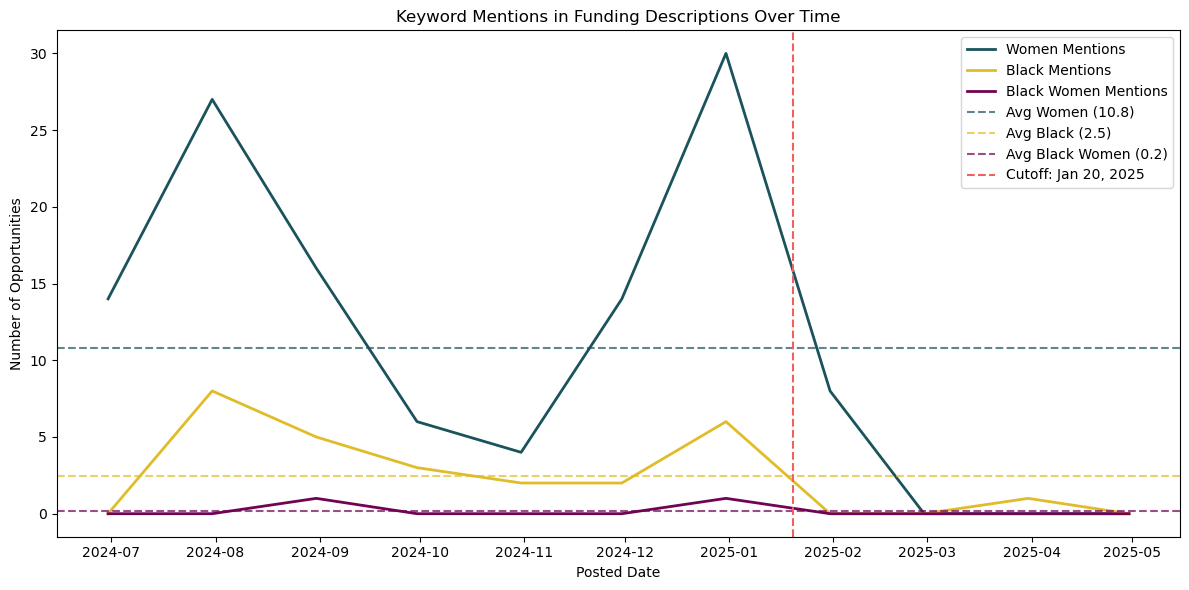

In [26]:
import pandas as pd
import re
import matplotlib.pyplot as plt


# Fill missing FUNDING DESCRIPTION
df['FUNDING DESCRIPTION'] = df['FUNDING DESCRIPTION'].fillna('')

# Lowercase FUNDING DESCRIPTION for easier matching
df['funding_description_lower'] = df['FUNDING DESCRIPTION'].str.lower()

# Compile word patterns
women_pattern = re.compile(r'\bwomen\b')
black_pattern = re.compile(r'\bblack\b')

# Identify rows that mention each term
df['mentions_women'] = df['funding_description_lower'].apply(lambda x: bool(women_pattern.search(x)))
df['mentions_black'] = df['funding_description_lower'].apply(lambda x: bool(black_pattern.search(x)))

# Identify rows that mention BOTH black AND women (anywhere in the description)
df['mentions_black_women'] = df['mentions_black'] & df['mentions_women']

# Set POSTED DATE as index for time series resampling
df = df.set_index('POSTED DATE')

# Resample monthly and count mentions
mentions_over_time = df[['mentions_women', 'mentions_black', 'mentions_black_women']].resample('M').sum()

# Calculate mean (monthly average) for each category
mean_women = mentions_over_time['mentions_women'].mean()
mean_black = mentions_over_time['mentions_black'].mean()
mean_black_women = mentions_over_time['mentions_black_women'].mean()

# Plotting
plt.figure(figsize=(12, 6))

# Plot each line
plt.plot(mentions_over_time.index, mentions_over_time['mentions_women'], label='Women Mentions', linewidth=2, color='#1A535C')
plt.plot(mentions_over_time.index, mentions_over_time['mentions_black'], label='Black Mentions', linewidth=2, color='#E1BC29')
plt.plot(mentions_over_time.index, mentions_over_time['mentions_black_women'], label='Black Women Mentions', linewidth=2, color='#700353')

# Add average lines
plt.axhline(mean_women, color='#1A535C', linestyle='--', alpha=0.7, label=f'Avg Women ({mean_women:.1f})')
plt.axhline(mean_black, color='#E1BC29', linestyle='--', alpha=0.7, label=f'Avg Black ({mean_black:.1f})')
plt.axhline(mean_black_women, color='#700353', linestyle='--', alpha=0.7, label=f'Avg Black Women ({mean_black_women:.1f})')

# Add vertical policy cutoff line
plt.axvline(pd.Timestamp('2025-01-20'), color='#F25F5C', linestyle='--', label='Cutoff: Jan 20, 2025')

plt.xlabel('Posted Date')
plt.ylabel('Number of Opportunities')
plt.title('Keyword Mentions in Funding Descriptions Over Time')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/funding_time.png', dpi=300)
plt.show()

